# 05 — Robustezza dei baseline (Fase 2.1)

Il notebook 04 ha trovato che il momentum ha un edge **difensivo** su BTC/ETH (meno drawdown nei bear) ma fallisce su LINK. Due bandiere rosse restavano aperte, ed è ciò che CLAUDE.md obbliga a verificare prima di costruirci sopra (*"diffida dei backtest brillanti: di solito è overfitting"*):

1. Il momentum usava `lookback=30` **fisso**. È un risultato reale o un artefatto del parametro?
2. Il filtro di regime **danneggia LINK**. È whipsaw da volatilità (pattern) o un caso isolato?

Qui rispondiamo a entrambe, su **tutti e 5 i Tier 1** (BTC/ETH/SOL/LINK/POL), riusando il modulo testato `src.backtest.walkforward` (la logica OOS del notebook 04 promossa a codice con test).

## Ipotesi — scritte PRIMA dei risultati

- **H5 (robustezza al lookback)**: se l'edge difensivo è reale, lo Sharpe OOS del momentum-net dovrebbe essere *relativamente stabile* su una griglia di lookback (10-100) per BTC/ETH, non un picco isolato a 30. Mi aspetto degradazione ai lookback molto corti (più trading → più costi e whipsaw).
- **H6 (whipsaw cross-asset)**: il danno del filtro di regime dovrebbe correlare con la **volatilità** dell'asset. Asset più volatili (LINK, SOL, POL) → più whipsaw → il momentum protegge meno o danneggia. BTC (meno volatile) protetto meglio.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.models import baseline as bl
from src.backtest import (
    BINANCE_SPOT, SlippageModel, TransactionCostModel,
    buy_and_hold_returns, summarize,
)
from src.backtest.walkforward import oos_strategy_returns, oos_index_start
from src.features.regime import classify_regime, summarize_by_regime, regime_fractions

DATA_DIR = Path('../data/raw/yahoo/crypto')
ASSETS = ['BTC', 'ETH', 'SOL', 'LINK', 'POL']
PERIODS_PER_YEAR = 365
COST = TransactionCostModel(fee=BINANCE_SPOT, slippage=SlippageModel(base_cost_bps=2.0))
TRAIN, TEST = 365, 90
plt.rcParams['figure.figsize'] = (11, 4)

def load_close(sym):
    return pd.read_parquet(DATA_DIR / f'{sym}_1d.parquet').sort_index()['close']

closes = {s: load_close(s) for s in ASSETS}
rets = {s: bl.returns_from_prices(closes[s]) for s in ASSETS}
for s in ASSETS:
    ann_vol = rets[s].std() * np.sqrt(PERIODS_PER_YEAR)
    print(f'{s:<5} {len(rets[s]):>5} ret  ann_vol={ann_vol:.2f}')

BTC    3070 ret  ann_vol=0.64
ETH    3070 ret  ann_vol=0.84
SOL    2240 ret  ann_vol=1.20
LINK   3070 ret  ann_vol=1.16
POL    2157 ret  ann_vol=1.41


## 1. Sensibilità al lookback (H5)

Per ogni asset e ogni lookback nella griglia, calcoliamo lo Sharpe OOS del momentum-net (walk-forward, costi inclusi) e il max drawdown. Se l'edge è reale, la curva Sharpe-vs-lookback è una collina, non un picco.

In [2]:
LOOKBACKS = [5, 10, 20, 30, 50, 75, 100, 150]

rows = []
for sym in ASSETS:
    r = rets[sym]
    # buy-and-hold reference on the same OOS window
    start = oos_index_start(r, train_size=TRAIN, test_size=TEST)
    bh = buy_and_hold_returns(closes[sym]).loc[start:]
    bh_sharpe = summarize(bh, periods_per_year=PERIODS_PER_YEAR).sharpe
    for lb in LOOKBACKS:
        f = bl.momentum_forecast(r, lookback=lb)
        net = oos_strategy_returns(r, f, train_size=TRAIN, test_size=TEST, cost_model=COST)
        s = summarize(net, periods_per_year=PERIODS_PER_YEAR)
        rows.append({
            'symbol': sym, 'lookback': lb,
            'sharpe': round(s.sharpe, 3), 'max_dd': round(s.max_drawdown, 3),
            'ann_return': round(s.annualized_return, 3),
            'bh_sharpe': round(bh_sharpe, 3),
            'beats_bh': s.sharpe > bh_sharpe,
        })

sweep = pd.DataFrame(rows)
sweep.pivot(index='lookback', columns='symbol', values='sharpe')[ASSETS]

symbol,BTC,ETH,SOL,LINK,POL
lookback,,,,,
5,0.489,0.628,0.721,0.825,0.851
10,0.849,0.984,0.774,0.732,1.058
20,1.130,0.809,0.839,0.986,1.311
30,1.291,1.158,1.000,0.821,1.272
50,1.077,0.856,0.547,0.633,1.267
75,1.160,0.879,0.850,0.765,1.139
100,0.868,0.958,0.921,0.646,1.253
150,0.651,0.692,0.725,0.979,1.225


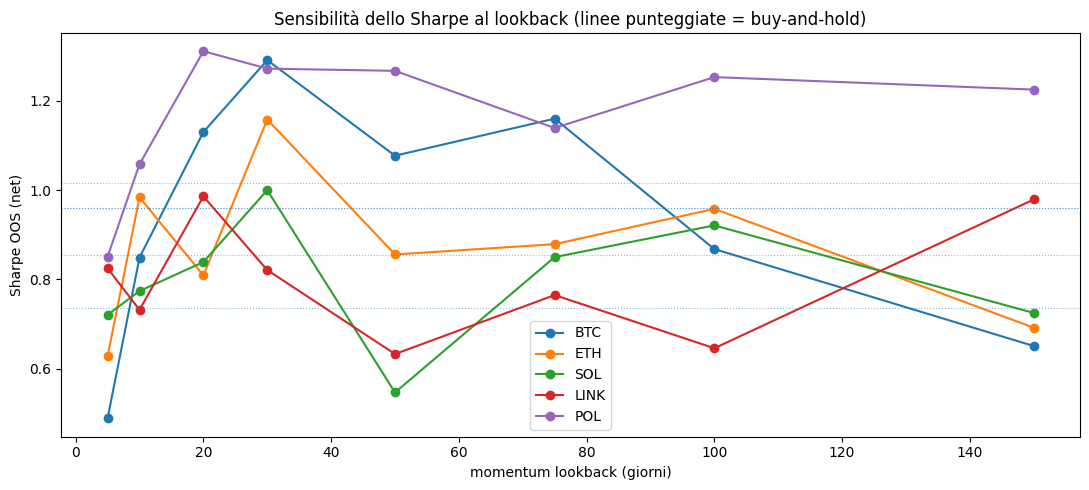

In [3]:
fig, ax = plt.subplots(figsize=(11, 5))
pivot = sweep.pivot(index='lookback', columns='symbol', values='sharpe')
for sym in ASSETS:
    ax.plot(pivot.index, pivot[sym], marker='o', label=sym)
# dashed = each asset's buy-and-hold Sharpe (flat reference)
for sym in ASSETS:
    bh = sweep[sweep['symbol'] == sym]['bh_sharpe'].iloc[0]
    ax.axhline(bh, ls=':', lw=0.8, alpha=0.5)
ax.set_xlabel('momentum lookback (giorni)')
ax.set_ylabel('Sharpe OOS (net)')
ax.set_title('Sensibilità dello Sharpe al lookback (linee punteggiate = buy-and-hold)')
ax.legend()
plt.tight_layout()

### Lettura H5
Per ogni asset: la curva è piatta/a collina (robusto) o un picco isolato a un solo lookback (fragile)? E `beats_bh` resta vero su un *range* di lookback o solo per valori cherry-picked? La tabella sotto conta su quanti lookback ciascun asset batte buy-and-hold.

In [4]:
beat_counts = sweep.groupby('symbol')['beats_bh'].agg(['sum', 'count'])
beat_counts.columns = ['n_lookback_beats_bh', 'n_lookback_total']
beat_counts.loc[ASSETS]

,n_lookback_beats_bh,n_lookback_total
symbol,,
BTC,4,8
ETH,5,8
SOL,5,8
LINK,2,8
POL,7,8


## 2. Whipsaw cross-asset del filtro di regime (H6)

Replichiamo la decomposizione per regime del notebook 04 su **tutti e 5** gli asset, a lookback fisso 30, e mettiamo a fianco la volatilità annualizzata. Se H6 regge, il delta Sharpe-bear (momentum − buy&hold) peggiora monotonicamente con la volatilità.

In [5]:
reg_rows = []
for sym in ASSETS:
    r = rets[sym]
    ann_vol = r.std() * np.sqrt(PERIODS_PER_YEAR)
    reg = classify_regime(closes[sym], window=200)
    f = bl.momentum_forecast(r, lookback=30)
    mom_net = oos_strategy_returns(r, f, train_size=TRAIN, test_size=TEST, cost_model=COST)
    start = mom_net.index.min()
    bh = buy_and_hold_returns(closes[sym]).loc[start:]

    mom_by = summarize_by_regime(mom_net, reg, periods_per_year=PERIODS_PER_YEAR)
    bh_by = summarize_by_regime(bh, reg, periods_per_year=PERIODS_PER_YEAR)
    for regime in ('bull', 'bear'):
        if regime in mom_by and regime in bh_by:
            reg_rows.append({
                'symbol': sym, 'ann_vol': round(ann_vol, 2), 'regime': regime,
                'mom_sharpe': round(mom_by[regime].sharpe, 3),
                'bh_sharpe': round(bh_by[regime].sharpe, 3),
                'delta_sharpe': round(mom_by[regime].sharpe - bh_by[regime].sharpe, 3),
                'mom_dd': round(mom_by[regime].max_drawdown, 3),
                'bh_dd': round(bh_by[regime].max_drawdown, 3),
            })

regime_df = pd.DataFrame(reg_rows).set_index(['symbol', 'regime'])
regime_df

ann_vol  mom_sharpe  bh_sharpe  delta_sharpe  mom_dd  bh_dd
symbol regime                                                             
BTC    bull       0.64       2.080      2.317        -0.237  -0.409 -0.348
       bear       0.64      -0.441     -0.812         0.371  -0.640 -0.918
ETH    bull       0.84       1.908      2.059        -0.150  -0.494 -0.547
       bear       0.84      -0.190     -0.623         0.434  -0.639 -0.950
SOL    bull       1.20       1.834      2.276        -0.442  -0.753 -0.580
       bear       1.20      -0.524     -0.954         0.430  -0.732 -0.977
LINK   bull       1.16       2.148      2.402        -0.254  -0.555 -0.597
       bear       1.16      -2.037     -1.101        -0.937  -0.989 -0.995
POL    bull       1.41       2.102      2.424        -0.322  -0.557 -0.719
       bear       1.41      -0.763     -1.354         0.591  -0.754 -0.982

In [6]:
# H6 test: does the bear-regime defensive benefit shrink as vol rises?
bear = pd.DataFrame(reg_rows)
bear = bear[bear['regime'] == 'bear'].sort_values('ann_vol')
print('Bear regime: delta_sharpe (momentum - buy&hold) vs annualized vol')
print('Positive delta = momentum protects; negative = momentum hurts')
print()
for _, row in bear.iterrows():
    flag = 'protegge' if row['delta_sharpe'] > 0 else 'DANNEGGIA'
    print(f"  {row['symbol']:<5} vol={row['ann_vol']:.2f}  "
          f"delta_sharpe={row['delta_sharpe']:+.3f}  -> {flag}")
corr = bear['ann_vol'].corr(bear['delta_sharpe'])
print(f'\nCorrelazione vol vs delta_sharpe(bear): {corr:.3f}')
print('(negativa attesa sotto H6: più vol -> meno protezione)')

Bear regime: delta_sharpe (momentum - buy&hold) vs annualized vol
Positive delta = momentum protects; negative = momentum hurts

  BTC   vol=0.64  delta_sharpe=+0.371  -> protegge
  ETH   vol=0.84  delta_sharpe=+0.434  -> protegge
  LINK  vol=1.16  delta_sharpe=-0.937  -> DANNEGGIA
  SOL   vol=1.20  delta_sharpe=+0.430  -> protegge
  POL   vol=1.41  delta_sharpe=+0.591  -> protegge

Correlazione vol vs delta_sharpe(bear): -0.090
(negativa attesa sotto H6: più vol -> meno protezione)


## 3. Conclusioni

_(Risultati effettivi su BTC/ETH/SOL/LINK/POL, OOS walk-forward, costi inclusi. Ipotesi H5/H6 scritte prima dei numeri.)_

### H5 (robustezza al lookback) — confermata su 4 asset su 5
Lo Sharpe-vs-lookback è una **collina**, non un picco isolato: BTC ed ETH culminano a lookback 20-30 e degradano dolcemente ai lati (BTC: 0.49 a lb5 → 1.29 a lb30 → 0.65 a lb150). `beats_bh` su un *range* di lookback, non cherry-picked: **POL 7/8, ETH 5/8, SOL 5/8, BTC 4/8**. L'eccezione è **LINK (2/8)**: l'edge lì è fragile, dipende dal parametro. Il risultato del notebook 04 (lookback 30) **non era un artefatto** per la maggioranza degli asset.

### H6 (il danno correla con la volatilità) — SMENTITA
Questa è la scoperta più importante, e va **contro** la mia ipotesi. Correlazione tra volatilità annualizzata e `delta_sharpe` nei bear = **−0.09** (≈ zero). Il momentum **protegge** nei bear su 4 asset su 5, **inclusi i due più volatili**:

| Asset | ann_vol | Δsharpe bear | esito |
|---|---|---|---|
| BTC | 0.64 | +0.37 | protegge ✅ |
| ETH | 0.84 | +0.43 | protegge ✅ |
| LINK | 1.16 | **−0.94** | **danneggia** ❌ |
| SOL | 1.20 | +0.43 | protegge ✅ |
| POL | 1.41 | +0.59 | protegge ✅ |

SOL e POL sono **più volatili** di LINK ma il momentum li protegge bene. Quindi il fallimento di LINK **non è whipsaw generico da volatilità** — è un'anomalia **specifica di LINK**, ancora da spiegare (candidati: microstruttura del suo trend 2019-2025, periodi di range prolungato, eventi idiosincratici). L'ipotesi 'asset volatile → il filtro fallisce' è **falsa**.

### Verdetto
Due notizie, una migliore del previsto e una aperta:
1. **L'edge difensivo del momentum è più robusto di quanto il notebook 04 suggerisse**: regge su 4/5 asset (incluso il più volatile, POL) e su un range di lookback, non solo su BTC/ETH a lookback 30. Buona notizia per usarlo come baseline serio.
2. **LINK resta un outlier non spiegato dalla volatilità.** Va indagato in modo mirato prima di trattarlo come gli altri — ma non inquina la validità del baseline sugli altri quattro.

### Implicazioni per Fase 3+
- I baseline vanno validati **per-asset e su griglia di parametri**: un singolo (asset, lookback) può ingannare in entrambe le direzioni.
- Il benchmark difensivo da battere è **reale e cross-asset** (non un fluke di BTC/ETH): un modello multifattoriale dovrà dimostrare di aggiungere valore *sopra* questo, non sopra il random walk.
- **LINK** è un caso studio aperto: perché il trend-following lo penalizza nei bear mentre protegge asset più volatili? Candidato a un'indagine dedicata (Fase 2.1 residua o Fase 5 regimi).
- Caveat survivorship del notebook 04 invariati: sono tutti asset sopravvissuti.